# Project 6 | Notebook 4: Publication-Quality Visualisation

## Overview

This notebook produces the final, publication-ready figures for Project 6.
It draws on the processed panel from Notebooks 1–3 and the analytical
findings from Notebooks 2–3 to produce a curated set of figures suitable
for inclusion in a working paper or research presentation.

All figures in this notebook are designed to meet basic cartographic
standards: consistent colour schemes, clean typography, proper legends
with units, and no chartjunk. Figures are exported in both PNG (300 dpi,
for digital display) and PDF (for print and presentation).

**Input:**
- `data/processed/districts_full_panel.gpkg` — full panel from Notebook 3

**Outputs:**
- `figures/pub_fig1_structural_transformation.png/pdf`
- `figures/pub_fig2_two_pathways.png/pdf`
- `figures/pub_fig3_trade_infrastructure.png/pdf`
- `figures/pub_fig4_correlation_summary.png/pdf`

**Design principles applied:**
- No background gridlines on maps (distracting, not standard in published maps)
- Common colour scales across temporally comparable panels
- Minimal axis decoration on maps (lat/lon labels removed — not needed
  for a reader who can see the map of India)
- Consistent font sizes: title 13pt, subtitle 11pt, legend 9pt
- Colour schemes chosen for both screen and greyscale print compatibility

In [1]:
# ─────────────────────────────────────────────────────────────
# Project 6 | Notebook 4: Publication Maps — Setup
# ─────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mapclassify
import numpy as np
from pathlib import Path
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, Normalize
from scipy import stats

# ── Paths ─────────────────────────────────────────────────────
PROJECT_ROOT = Path('..')
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
FIGURES      = PROJECT_ROOT / 'figures'

# ── Publication plot style ────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 10,
    'axes.titlesize'   : 11,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
})

# ── Helper: clean map axes ────────────────────────────────────
def clean_map_ax(ax, title=None):
    """Remove gridlines, axis labels and ticks for a clean map."""
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

# ── Load panel ────────────────────────────────────────────────
panel = gpd.read_file(DATA_PROC / 'districts_full_panel.gpkg')
print(f"Panel loaded: {panel.shape}")
print(f"CRS: {panel.crs}")

Panel loaded: (640, 43)
CRS: EPSG:4326


## Figure 1 — The Geography of Structural Transformation, 1990–2013

A four-panel choropleth showing non-farm employment share across Indian
districts for each Economic Census round. Common quantile classification
applied to the pooled distribution across all four rounds ensures
direct temporal comparability. Grey districts indicate missing data
(EC1990 coverage gaps documented in Notebook 1).

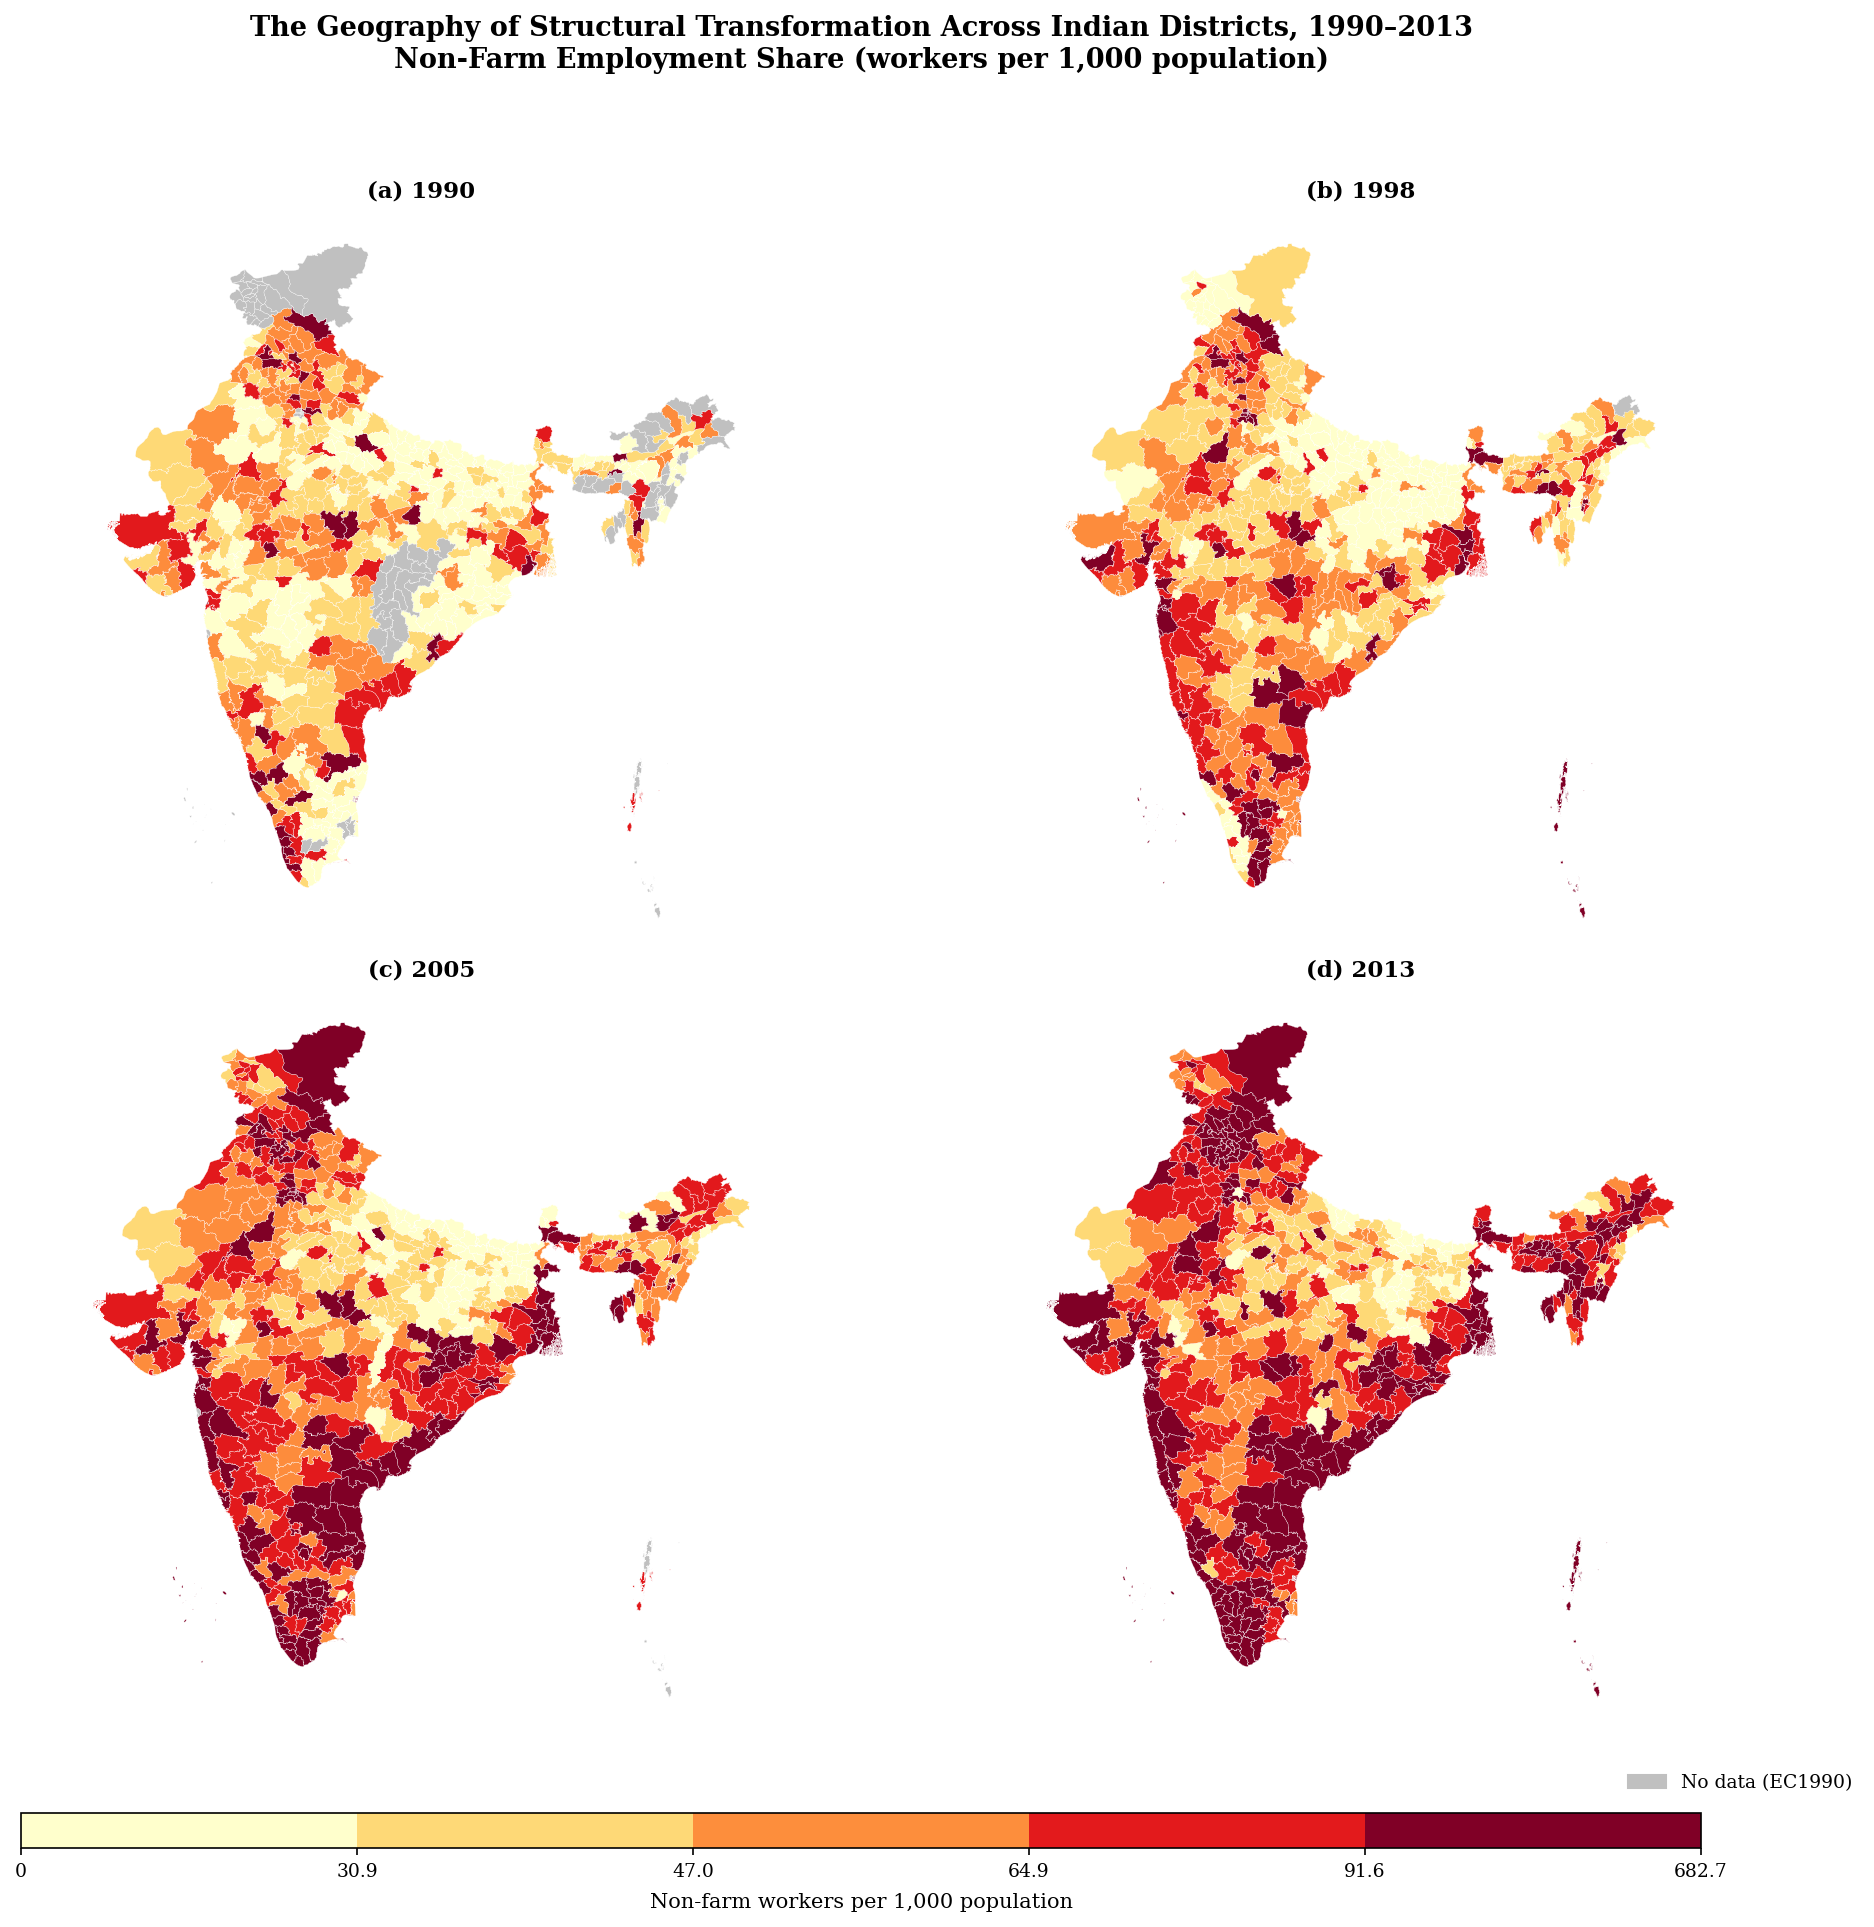

Figure 1 saved.


In [2]:
# ─────────────────────────────────────────────────────────────
# Figure 1 — Structural transformation panel (publication quality)
# ─────────────────────────────────────────────────────────────

nonfarm_cols = ['nonfarm_share_90', 'nonfarm_share_98',
                'nonfarm_share_05', 'nonfarm_share_13']
pooled       = pd.concat([panel[c].dropna() for c in nonfarm_cols])
breaks       = mapclassify.Quantiles(pooled, k=5).bins

panel_labels = ['(a) 1990', '(b) 1998', '(c) 2005', '(d) 2013']
cmap         = plt.cm.YlOrRd

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes      = axes.flatten()

for i, (col, label) in enumerate(zip(nonfarm_cols, panel_labels)):
    ax = axes[i]

    panel.plot(
        column              = col,
        ax                  = ax,
        scheme              = 'user_defined',
        classification_kwds = {'bins': breaks},
        cmap                = cmap,
        legend              = False,
        missing_kwds        = {
            'color' : '#c0c0c0',
            'label' : 'No data'
        },
        edgecolor           = 'white',
        linewidth           = 0.15
    )

    clean_map_ax(ax, title=label)

# ── Shared horizontal colorbar ────────────────────────────────
norm = BoundaryNorm([0] + list(breaks), cmap.N)
sm   = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.018])
cbar    = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Non-farm workers per 1,000 population',
               fontsize=10, labelpad=6)
tick_vals   = [0] + list(breaks)
tick_labels = ['0', '30.9', '47.0', '64.9', '91.6', '682.7']
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_labels, fontsize=9)

# ── No-data legend patch ──────────────────────────────────────
no_data_patch = mpatches.Patch(color='#c0c0c0', label='No data (EC1990)')
fig.legend(handles=[no_data_patch], loc='lower right',
           fontsize=9, frameon=False,
           bbox_to_anchor=(0.92, 0.06))

fig.suptitle(
    'The Geography of Structural Transformation Across Indian Districts, '
    '1990–2013\nNon-Farm Employment Share (workers per 1,000 population)',
    fontsize=13, fontweight='bold', y=0.98
)

plt.subplots_adjust(hspace=0.05, wspace=0.02, bottom=0.1)
plt.savefig(FIGURES / 'pub_fig1_structural_transformation.png')
plt.savefig(FIGURES / 'pub_fig1_structural_transformation.pdf')
plt.show()
print("Figure 1 saved.")

### Figure 1 — Output

Publication-quality four-panel structural transformation map.
Saved as PNG (300 dpi) and PDF.

The figure documents the persistent spatial hierarchy of structural
transformation across India's 640 districts over the full
post-liberalisation period. The progressive darkening from panel (a)
to panel (d) — most pronounced in the coastal south, Gujarat, and
the NCR belt — against a persistently pale central and eastern
interior constitutes the core spatial finding of this project.

## Figure 2 — Two Pathways of Structural Transformation: 1990 vs 2013

Manufacturing share of non-farm employment in 1990 and 2013 side by
side. Districts that darkened indicate increasing manufacturing
intensity — the classic industrialisation pathway. Districts that
lightened transitioned into services without a manufacturing phase.

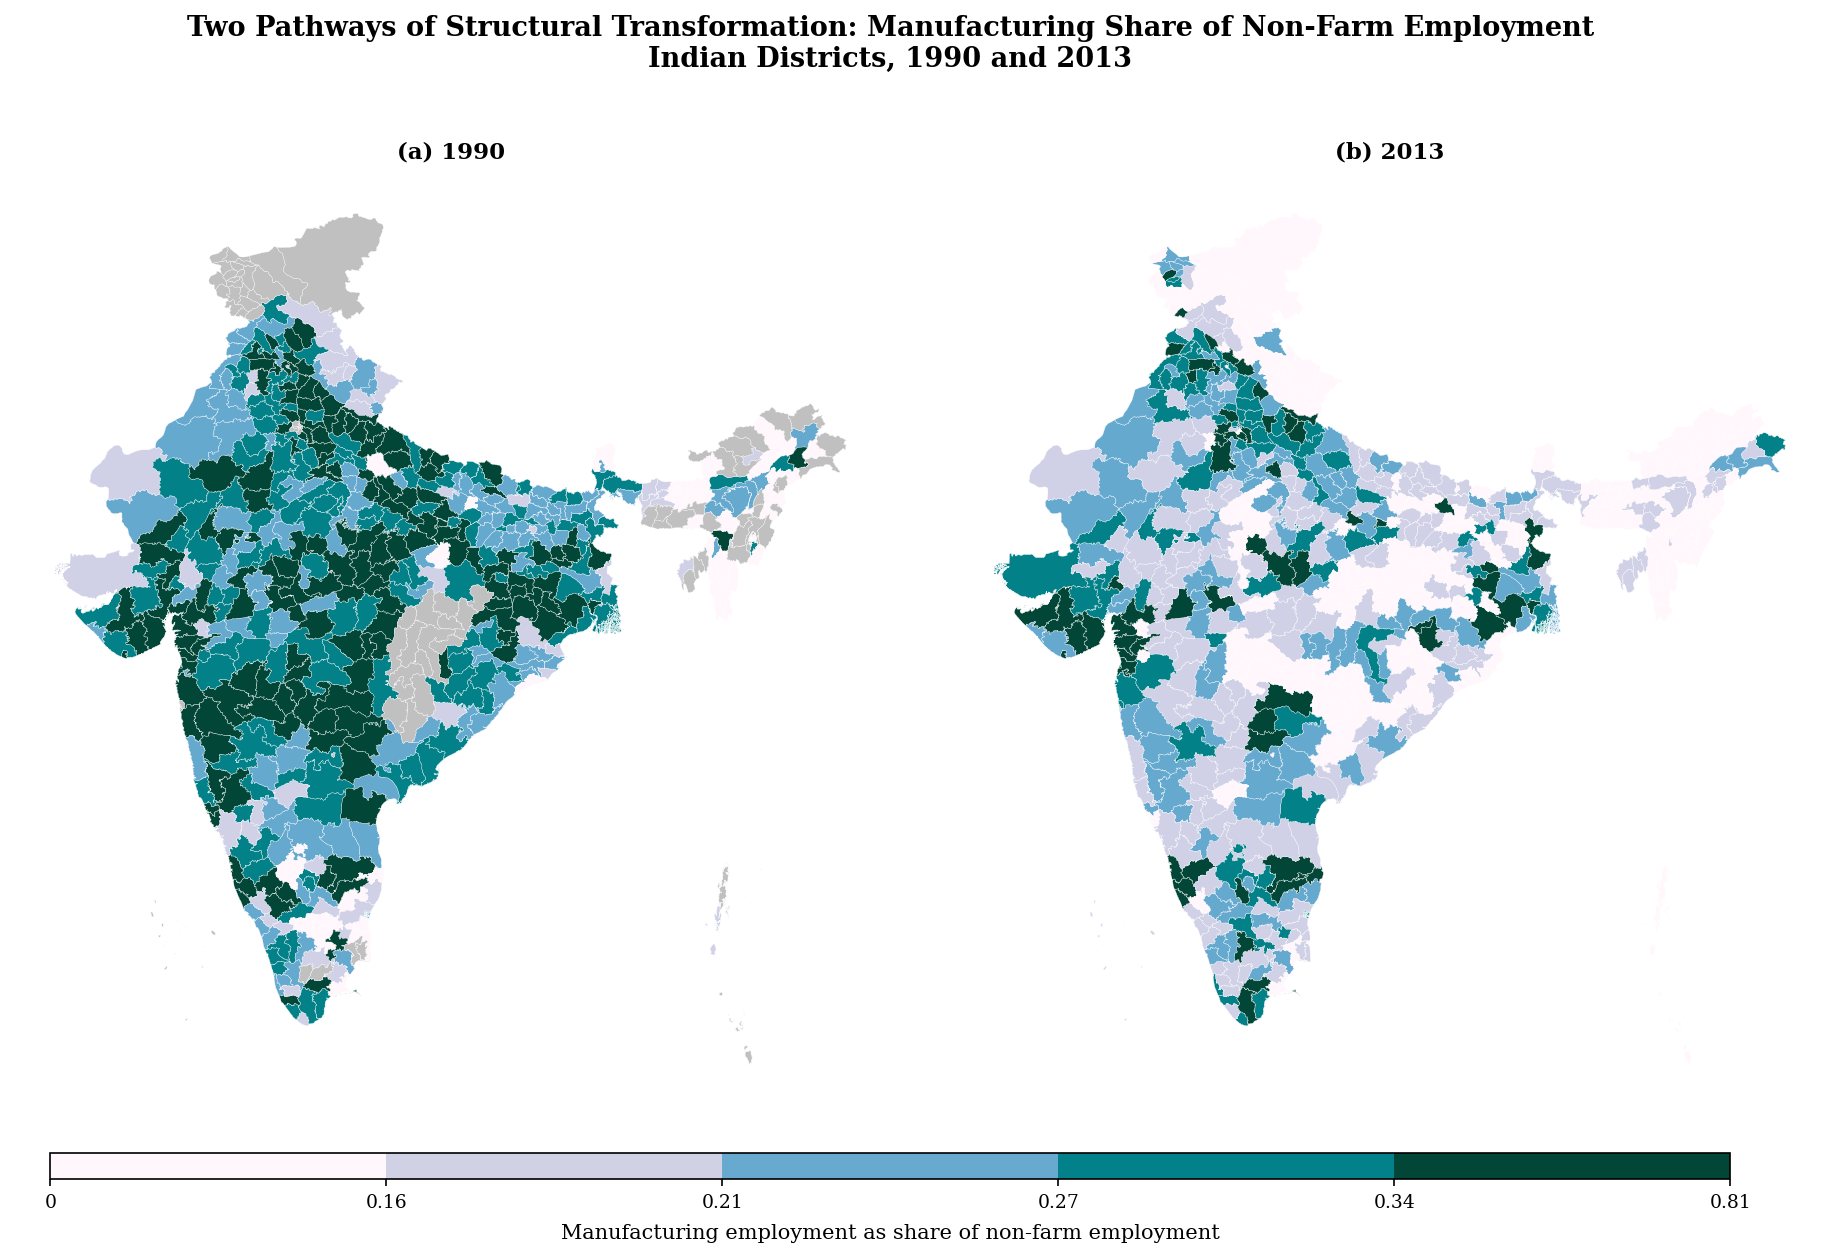

Figure 2 saved.


In [3]:
# ─────────────────────────────────────────────────────────────
# Figure 2 — Two pathways: manufacturing share 1990 vs 2013
# ─────────────────────────────────────────────────────────────

manuf_cols   = ['manuf_share_90', 'manuf_share_13']
pooled_m     = pd.concat([panel[c].dropna() for c in manuf_cols])
breaks_m     = mapclassify.Quantiles(pooled_m, k=5).bins
cmap_m       = plt.cm.PuBuGn

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

subtitles = ['(a) 1990', '(b) 2013']
for i, (col, subtitle) in enumerate(zip(manuf_cols, subtitles)):
    ax = axes[i]
    panel.plot(
        column              = col,
        ax                  = ax,
        scheme              = 'user_defined',
        classification_kwds = {'bins': breaks_m},
        cmap                = cmap_m,
        legend              = False,
        missing_kwds        = {'color': '#c0c0c0'},
        edgecolor           = 'white',
        linewidth           = 0.15
    )
    clean_map_ax(ax, title=subtitle)

# Shared colorbar
norm_m = BoundaryNorm([0] + list(breaks_m), cmap_m.N)
sm_m   = ScalarMappable(cmap=cmap_m, norm=norm_m)
sm_m.set_array([])

cbar_ax = fig.add_axes([0.15, 0.04, 0.7, 0.022])
cbar_m  = fig.colorbar(sm_m, cax=cbar_ax, orientation='horizontal')
cbar_m.set_label('Manufacturing employment as share of non-farm employment',
                 fontsize=10, labelpad=6)
cbar_m.set_ticks([0] + list(breaks_m))
cbar_m.set_ticklabels(
    ['0'] + [f'{b:.2f}' for b in breaks_m], fontsize=9)

fig.suptitle(
    'Two Pathways of Structural Transformation: '
    'Manufacturing Share of Non-Farm Employment\n'
    'Indian Districts, 1990 and 2013',
    fontsize=13, fontweight='bold', y=1.01
)

plt.subplots_adjust(wspace=0.02, bottom=0.1)
plt.savefig(FIGURES / 'pub_fig2_two_pathways.png')
plt.savefig(FIGURES / 'pub_fig2_two_pathways.pdf')
plt.show()
print("Figure 2 saved.")

### Figure 2 — Output

Saved as PNG (300 dpi) and PDF.

The comparison reveals the fragmentation of India's manufacturing
geography over the post-liberalisation period. In 1990, high
manufacturing share was widespread — reflecting a narrow non-farm
base dominated by traditional manufacturing. By 2013, distinct
manufacturing clusters have emerged (Gujarat coast, northern plains
industrial belt, select Tamil Nadu and Karnataka districts) while
large parts of the south and east have lightened — consistent with
services-led transformation. The overall darkening of Figure 1
combined with the lightening of Figure 2 documents India's partial
premature deindustrialisation at the district level.

## Figure 3 — Trade Infrastructure Proximity and Structural Change

Three-panel figure placing port distance, SEZ proximity, and 2013
non-farm employment share side by side. Port and SEZ triangles/squares
overlaid on their respective distance maps. This is the spatial
argument of the project in a single figure.

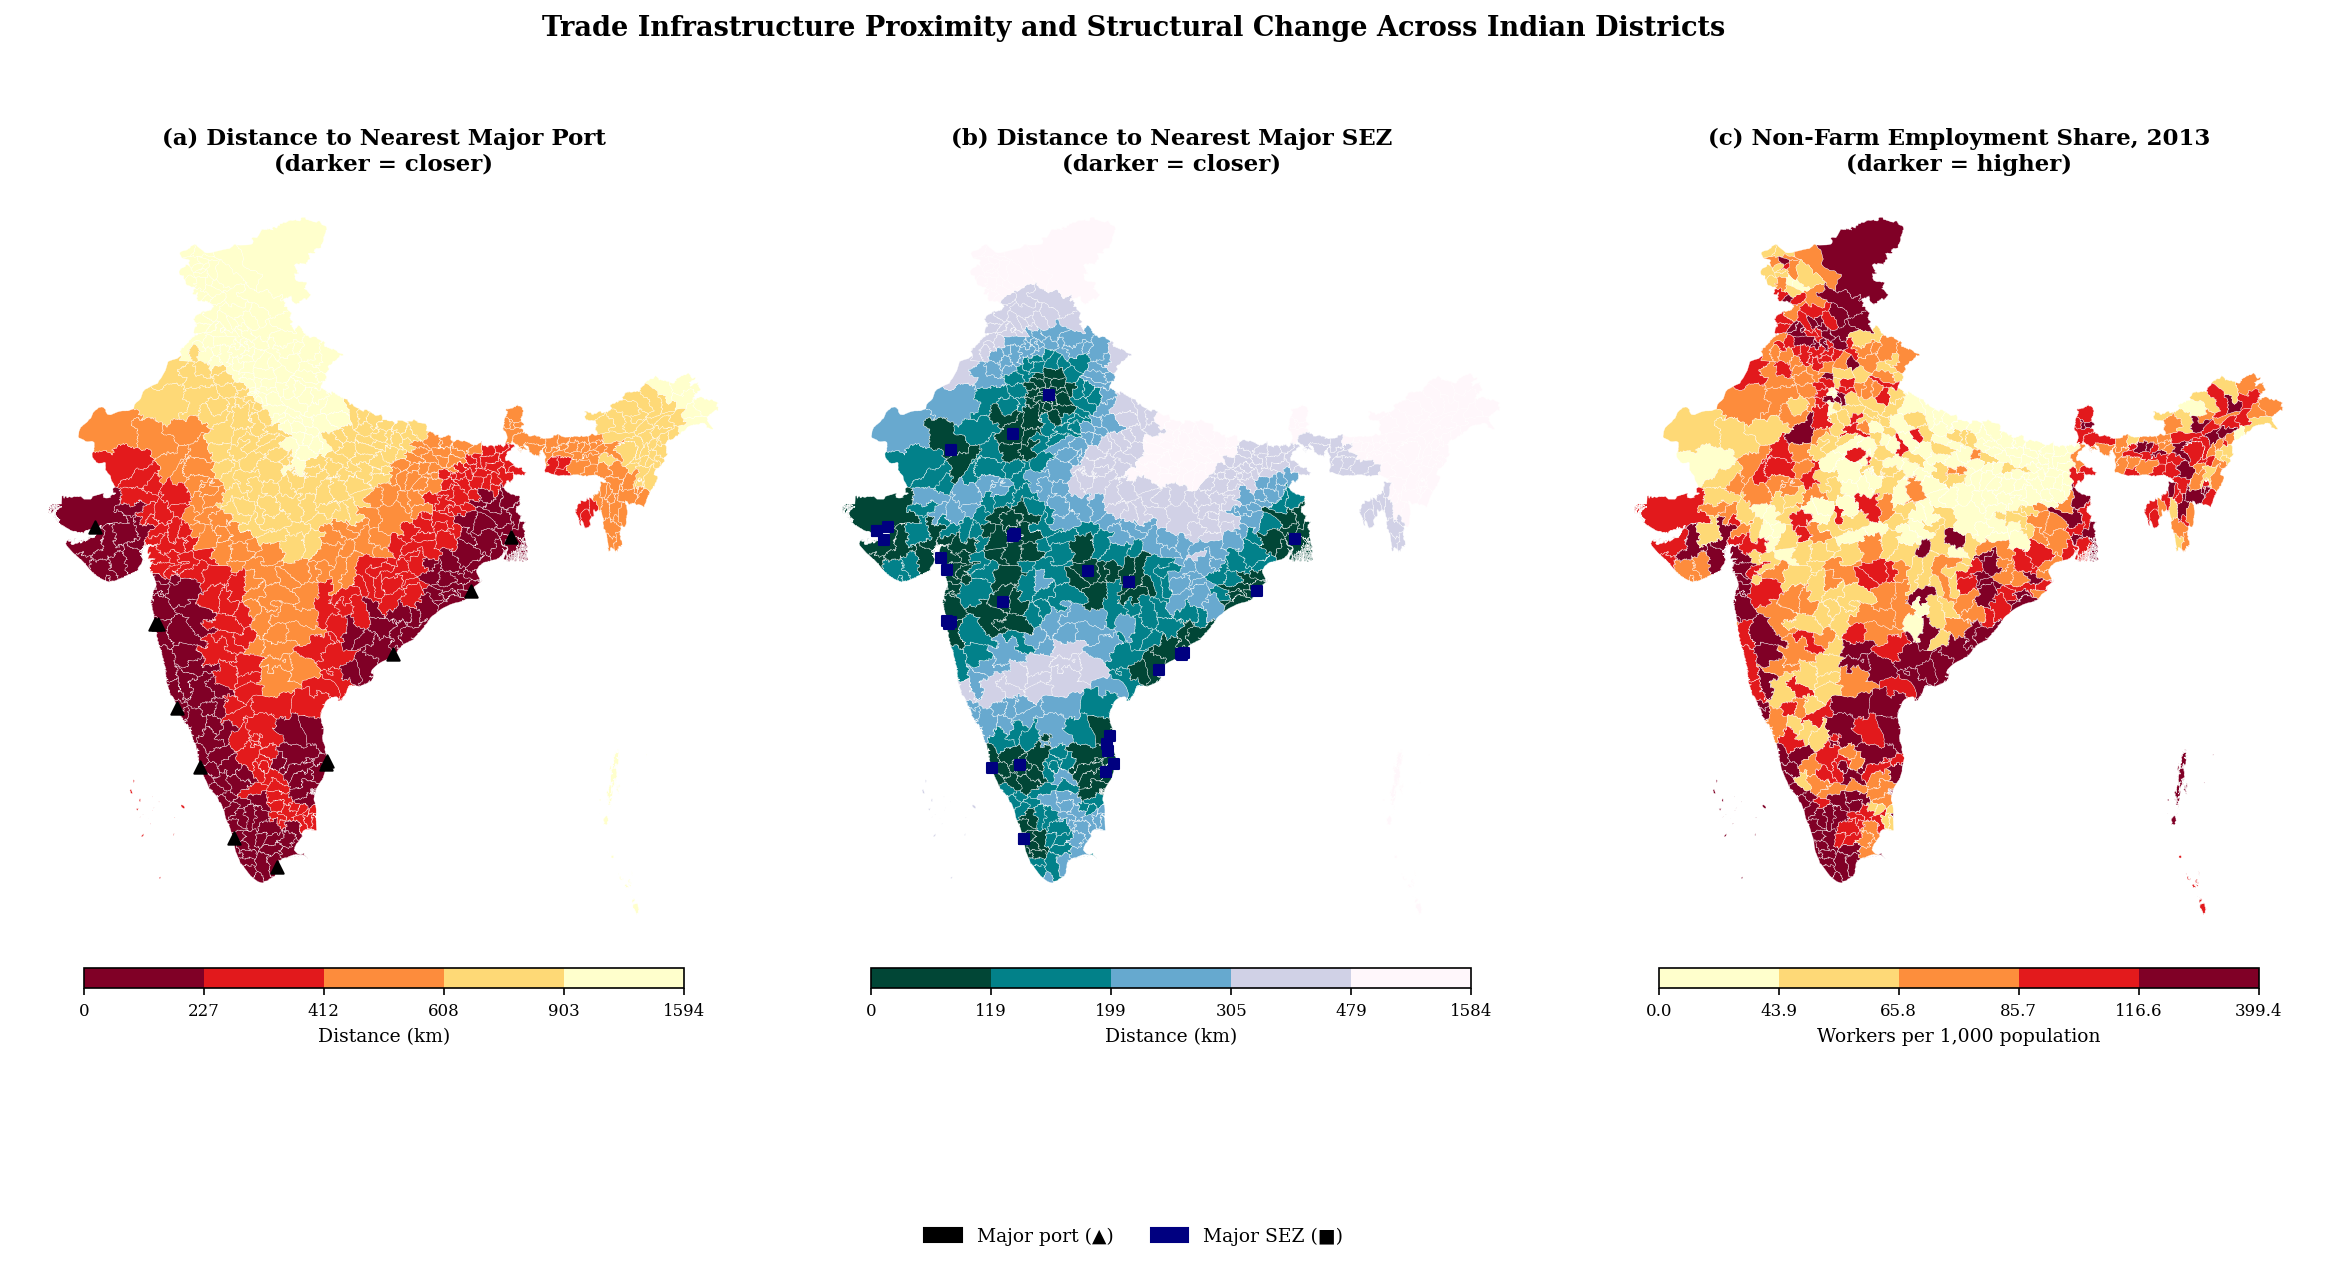

Figure 3 saved.


In [4]:
# ─────────────────────────────────────────────────────────────
# Figure 3 — Trade infrastructure and structural change (3-panel)
# ─────────────────────────────────────────────────────────────

# Reload infrastructure data
ports_gdf = gpd.read_file(
    PROJECT_ROOT / 'data' / 'raw' / 'infrastructure' / 
    'major_sezs.geojson'
).pipe(lambda x: x)  # placeholder — we'll use hardcoded ports below

# Recreate ports GeoDataFrame
import geopandas as gpd
from shapely.geometry import Point

ports_data = {
    'port': ['Kandla','Mumbai','JNPT','Mormugao','New Mangalore',
             'Kochi','Chennai','Ennore','Tuticorin',
             'Visakhapatnam','Paradip','Kolkata-Haldia'],
    'latitude' : [23.0035,18.9322,18.9490,15.4066,12.9236,
                  9.9624,13.0827,13.2039,8.7642,
                  17.6868,20.3167,22.5726],
    'longitude': [70.2193,72.8355,72.9442,73.8028,74.7874,
                  76.2673,80.2707,80.3273,78.1348,
                  83.2185,86.6083,88.3639]
}
ports_gdf = gpd.GeoDataFrame(
    ports_data,
    geometry = gpd.points_from_xy(
        ports_data['longitude'], ports_data['latitude']),
    crs = 'EPSG:4326'
)

sez_gdf = gpd.read_file(
    PROJECT_ROOT / 'data' / 'raw' / 'infrastructure' / 
    'major_sezs.geojson'
)

# ── Common scales ─────────────────────────────────────────────
breaks_port = mapclassify.Quantiles(
    panel['dist_port_km'].dropna(), k=5).bins
breaks_sez  = mapclassify.Quantiles(
    panel['dist_sez_km'].dropna(), k=5).bins
breaks_nf   = mapclassify.Quantiles(
    panel['nonfarm_share_13'].dropna(), k=5).bins

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# ── Panel (a): Port distance ──────────────────────────────────
panel.plot(
    column              = 'dist_port_km',
    ax                  = axes[0],
    scheme              = 'user_defined',
    classification_kwds = {'bins': breaks_port},
    cmap                = 'YlOrRd_r',
    legend              = False,
    edgecolor           = 'white',
    linewidth           = 0.15
)
ports_gdf.plot(ax=axes[0], color='black', markersize=35,
               marker='^', zorder=5)
clean_map_ax(axes[0], title='(a) Distance to Nearest Major Port\n'
                             '(darker = closer)')

norm_p = BoundaryNorm([0]+list(breaks_port), plt.cm.YlOrRd_r.N)
sm_p   = ScalarMappable(cmap=plt.cm.YlOrRd_r, norm=norm_p)
sm_p.set_array([])
cb_p   = fig.colorbar(sm_p, ax=axes[0], orientation='horizontal',
                       shrink=0.8, pad=0.02, aspect=30)
cb_p.set_label('Distance (km)', fontsize=9)
cb_p.ax.tick_params(labelsize=8)

# ── Panel (b): SEZ distance ───────────────────────────────────
panel.plot(
    column              = 'dist_sez_km',
    ax                  = axes[1],
    scheme              = 'user_defined',
    classification_kwds = {'bins': breaks_sez},
    cmap                = 'PuBuGn_r',
    legend              = False,
    edgecolor           = 'white',
    linewidth           = 0.15
)
sez_gdf.plot(ax=axes[1], color='navy', markersize=25,
             marker='s', zorder=5)
clean_map_ax(axes[1], title='(b) Distance to Nearest Major SEZ\n'
                             '(darker = closer)')

norm_s = BoundaryNorm([0]+list(breaks_sez), plt.cm.PuBuGn_r.N)
sm_s   = ScalarMappable(cmap=plt.cm.PuBuGn_r, norm=norm_s)
sm_s.set_array([])
cb_s   = fig.colorbar(sm_s, ax=axes[1], orientation='horizontal',
                       shrink=0.8, pad=0.02, aspect=30)
cb_s.set_label('Distance (km)', fontsize=9)
cb_s.ax.tick_params(labelsize=8)

# ── Panel (c): Non-farm share 2013 ────────────────────────────
panel.plot(
    column              = 'nonfarm_share_13',
    ax                  = axes[2],
    scheme              = 'user_defined',
    classification_kwds = {'bins': breaks_nf},
    cmap                = 'YlOrRd',
    legend              = False,
    edgecolor           = 'white',
    linewidth           = 0.15
)
clean_map_ax(axes[2], title='(c) Non-Farm Employment Share, 2013\n'
                             '(darker = higher)')

norm_n = BoundaryNorm([0]+list(breaks_nf), plt.cm.YlOrRd.N)
sm_n   = ScalarMappable(cmap=plt.cm.YlOrRd, norm=norm_n)
sm_n.set_array([])
cb_n   = fig.colorbar(sm_n, ax=axes[2], orientation='horizontal',
                       shrink=0.8, pad=0.02, aspect=30)
cb_n.set_label('Workers per 1,000 population', fontsize=9)
cb_n.ax.tick_params(labelsize=8)

# ── Shared legend for infrastructure markers ──────────────────
port_marker = mpatches.RegularPolygon((0,0), 3, radius=0.1,
    color='black', label='Major port (▲)')
sez_marker  = mpatches.Patch(color='navy',
    label='Major SEZ (■)')
fig.legend(handles=[port_marker, sez_marker],
           loc='lower center', ncol=2, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Trade Infrastructure Proximity and Structural Change '
    'Across Indian Districts',
    fontsize=13, fontweight='bold', y=1.02
)

plt.subplots_adjust(wspace=0.05)
plt.savefig(FIGURES / 'pub_fig3_trade_infrastructure.png')
plt.savefig(FIGURES / 'pub_fig3_trade_infrastructure.pdf')
plt.show()
print("Figure 3 saved.")

### Figure 3 — Output

Saved as PNG (300 dpi) and PDF.

The three-panel figure presents the spatial argument of the project
in a single view. Reading left to right: districts darker in (a)
and (b) — closer to ports and SEZs — tend to be darker in (c) —
higher non-farm employment share. The correspondence is clearest
along the western and southern coasts. Divergences — the pale
northeast in (c) despite moderate SEZ proximity in (b), and the
dark north in (c) despite distance from both ports and SEZs — are
precisely the analytically interesting cases documented in Notebook 3.

## Figure 4 — Correlation Summary: Proximity and Structural Change

Publication-quality scatter plots quantifying the relationship between
trade infrastructure proximity and non-farm employment share. Presented
as a 1×2 panel with regression lines and correlation statistics.
The corridor box plot is omitted from the publication figure given
the ecological confounding documented in Notebook 3 — including it
without adequate explanation would be misleading.

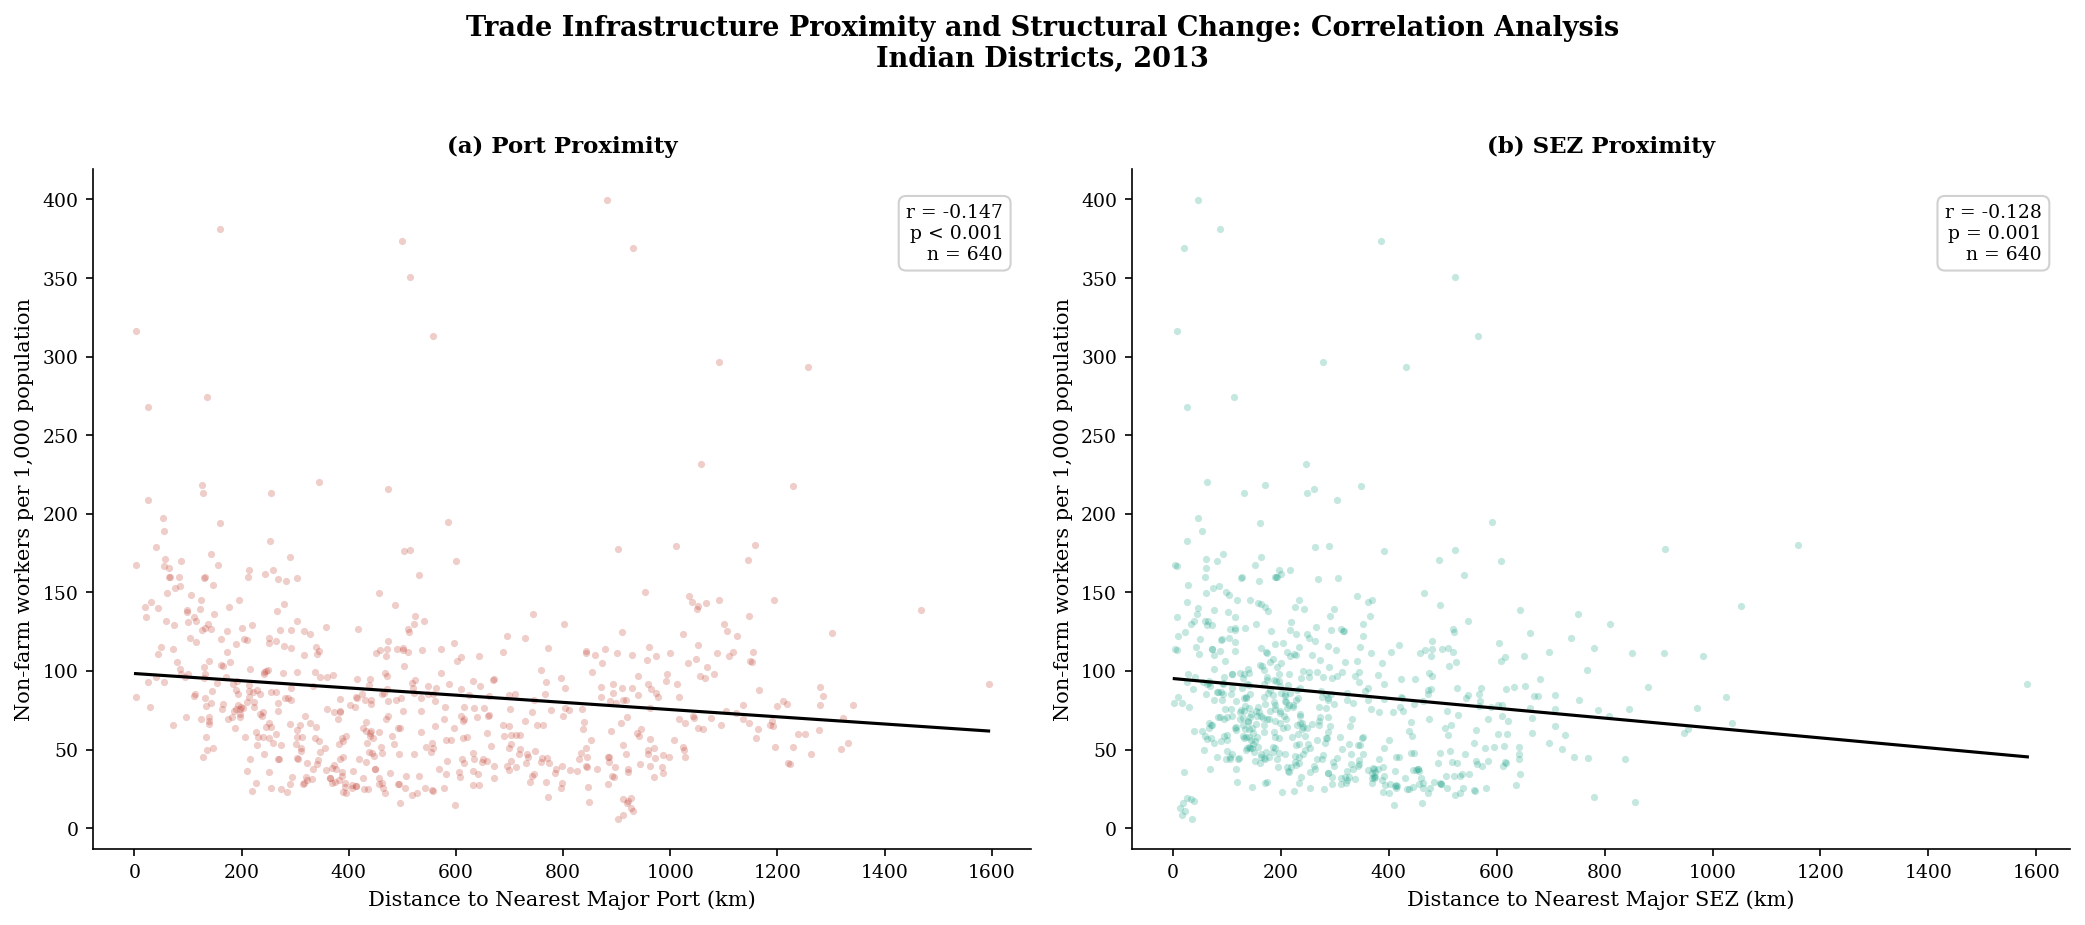

Figure 4 saved.


In [5]:
# ─────────────────────────────────────────────────────────────
# Figure 4 — Correlation summary (publication quality)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_vars = [
    ('dist_port_km', 'nonfarm_share_13',
     'Distance to Nearest Major Port (km)',
     '(a) Port Proximity', '#c0392b'),
    ('dist_sez_km',  'nonfarm_share_13',
     'Distance to Nearest Major SEZ (km)',
     '(b) SEZ Proximity', '#16a085'),
]

for ax, (xvar, yvar, xlabel, title, colour) in zip(axes, scatter_vars):
    x    = panel[xvar].dropna()
    y    = panel.loc[x.index, yvar]
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    r, p = stats.pearsonr(x, y)
    m, b = np.polyfit(x, y, 1)

    ax.scatter(x, y, alpha=0.25, s=12, color=colour, linewidths=0)

    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b,
            color='black', linewidth=1.5, zorder=5)

    # Annotation box
    p_str = '< 0.001' if p < 0.001 else f'= {p:.3f}'
    ax.annotate(
        f'r = {r:.3f}\np {p_str}\nn = {len(x)}',
        xy         = (0.97, 0.95),
        xycoords   = 'axes fraction',
        ha         = 'right',
        va         = 'top',
        fontsize   = 9,
        bbox       = dict(boxstyle='round,pad=0.4',
                          facecolor='white',
                          edgecolor='#cccccc',
                          alpha=0.9)
    )

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Non-farm workers per 1,000 population', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)

fig.suptitle(
    'Trade Infrastructure Proximity and Structural Change: '
    'Correlation Analysis\nIndian Districts, 2013',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(FIGURES / 'pub_fig4_correlation_summary.png')
plt.savefig(FIGURES / 'pub_fig4_correlation_summary.pdf')
plt.show()
print("Figure 4 saved.")

### Figure 4 — Output

Saved as PNG (300 dpi) and PDF.

Both panels show statistically significant negative correlations —
closer districts have higher non-farm employment share — but the
modest magnitudes (r = -0.147 and r = -0.128) and substantial
dispersion make clear that trade infrastructure proximity is one
factor among many. The wide vertical spread at every distance value
reflects the role of state-level industrial policy, agglomeration
economies, and historical industrial base in shaping structural
change outcomes independently of geographic proximity to trade
infrastructure.

## Notebook 4 — Summary

This notebook produced four publication-quality figures from the
analytical work of Notebooks 1–3:

| Figure | File | Content |
|---|---|---|
| Figure 1 | `pub_fig1_structural_transformation.png/pdf` | Four-panel non-farm share, 1990–2013 |
| Figure 2 | `pub_fig2_two_pathways.png/pdf` | Manufacturing share 1990 vs 2013 |
| Figure 3 | `pub_fig3_trade_infrastructure.png/pdf` | Port distance, SEZ proximity, non-farm share |
| Figure 4 | `pub_fig4_correlation_summary.png/pdf` | Correlation scatter plots |

All figures use serif fonts, 300 dpi output, clean map axes, and
consistent colour schemes. PDF versions are suitable for inclusion
in a working paper or research presentation without further editing.

**Project 6 is now complete.**

The four-notebook pipeline has produced:
- A district-level panel of structural change indicators across four
  Economic Census rounds (1990–2013), harmonised to 2011 boundaries
- Three trade exposure proxy measures (port distance, SEZ proximity,
  corridor alignment) for all 640 Indian districts
- Eight analytical maps and four publication-quality figures
- A transparent, well-documented methodology including honest
  treatment of data quality issues, boundary harmonisation challenges,
  and the limitations of proxy-based trade exposure measurement